# **Graph**

Graph adalah struktur data non-linear yang terdiri dari sekumpulan titik yang saling terhubung. Graph digunakan untuk merepresentasikan jaringan di dunia nyata, seperti jaringan jalan raya, pertemanan di media sosial, atau topologi jaringan komputer.<br>

Graph terdiri dari dua komponen utama:

- Vertex (Node/Simpul) : Entitas atau data itu sendiri (biasanya dilambangkan dengan huruf atau angka)
- Edge (Sisi/Garis) : Jalur yang menghubungkan dua buah Vertex.

Berdasarkan Arahnya (Direction), Graph dibagi menjadi dua:

- Undirected Graph (Graph Tak Berarah): Sisi tidak memiliki arah. Jika ada edge antara A dan B, maka A bisa ke B dan B bisa ke A (komunikasi dua arah).
- Directed Graph (Graph Berarah / Digraph): Sisi memiliki arah. Jika ada edge dari A ke B, kita hanya bisa pergi dari A ke B, tidak berlaku sebaliknya kecuali ada edge lain dari B ke A.

# **Adjacency list**

Adjacency List merepresentasikan graph sebagai Array yang berisi List (atau LinkedList). Indeks dari array mewakili vertex, dan List pada indeks tersebut berisi semua vertex tetangga yang terhubung langsung dengannya.

- Kelebihan: Sangat hemat memori untuk graph yang renggang karena hanya menyimpan edge yang benar-benar ada. Kompleksitas ruangnya $O(V + E)$.
- Kekurangan: Butuh waktu lebih lama untuk mengecek keberadaan edge spesifik dibanding matriks.

umumnya graph(adjacency list) dibuat menggunakan Dictionary Of List atau Dictionary of Dictionary

In [12]:
Adjlist = {
    'Solo':{
        'Semarang':{"Jarak" : 110},
        'Yogya' : {"Jarak" : 65}
    },
    'Yogya':{
        'Magelang':{"Jarak" : 45}
    },
    'Semarang':{
        'Salatiga':{"Jarak" :52}
    },
    'Salatiga':{
        'Yogya':{"Jarak" : 75}
    },
    'Magelang':{
        'Semarang':{"Jarak" : 95}
    }

}

In [26]:
class Graph:
    def __init__ (self,directed=False):
        self.graph={}
        self.directed=directed
    
    def add_vertex (self,v):
        if v not in self.graph:
            self.graph[v] = {}
    
    def add_edge (self,u,v,weight=None):
        self.add_vertex(u)
        self.add_vertex(v)

        self.graph[u][v] = {"weight": weight}

        # jika undirected
        if not self.directed:
            self.graph[v][u] = {"weight": weight}

    def del_vertex(self, u):

        if u not in self.graph:
            print(f"graph {u} tidak ada")

        else:

            # hapus semua edge menuju u
            for vertex in self.graph:
                if u in self.graph[vertex]:
                    del self.graph[vertex][u]

            # hapus node utama
            del self.graph[u]
            
    def show(self):
        print(self.graph)

In [28]:
g = Graph(directed=False)

# Tambah node / vertex
g.add_vertex("A")
g.add_vertex("B")
g.add_vertex("C")

# tambah edge
g.add_edge("A", "B", 5)
g.add_edge("A", "C", 2)
g.add_edge("B", "D", 4)
g.add_edge("C", "D", 7)



g.show()


{'A': {'B': {'weight': 5}, 'C': {'weight': 2}}, 'B': {'A': {'weight': 5}, 'D': {'weight': 4}}, 'C': {'A': {'weight': 2}, 'D': {'weight': 7}}, 'D': {'B': {'weight': 4}, 'C': {'weight': 7}}}


# **Networkx** 

Nodes: ['Solo', 'Yogya', 'Semarang', 'Salatiga', 'Magelang']
Edges: [('Solo', 'Semarang', {'weight': 110}), ('Solo', 'Yogya', {'weight': 65}), ('Yogya', 'Magelang', {'weight': 45}), ('Yogya', 'Salatiga', {'weight': 75}), ('Semarang', 'Salatiga', {'weight': 52}), ('Semarang', 'Magelang', {'weight': 95})]
Degree Solo: 2
Rute: Solo → Yogya → Magelang
Jarak: 110


{('Solo', 'Semarang'): Text(-0.06546999864002179, -0.23413694772193894, '110'),
 ('Solo', 'Yogya'): Text(0.4398819873952158, 0.03587676597615763, '65'),
 ('Yogya', 'Magelang'): Text(0.1724717473528361, -0.2658646095147652, '45'),
 ('Yogya', 'Salatiga'): Text(0.15527590288752124, 0.6899031551540966, '75'),
 ('Semarang',
  'Salatiga'): Text(-0.3500765545954897, 0.41988792951968956, '52'),
 ('Semarang',
  'Magelang'): Text(-0.3328828265838498, -0.5358853118135564, '95')}

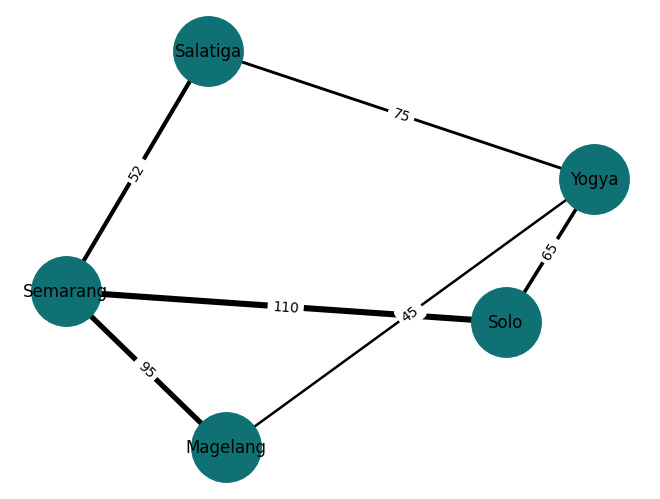

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
cities = ['Solo','Yogya','Semarang','Salatiga','Magelang']
G.add_nodes_from(cities)

edges = [('Solo','Semarang',110),('Solo','Yogya',65),('Yogya','Magelang',45),
        ('Semarang','Salatiga',52),('Salatiga','Yogya',75),('Magelang','Semarang',95)]

G.add_weighted_edges_from(edges)


# --Analisis Graf--
print('Nodes:',G.nodes())
print('Edges:',G.edges(data=True))
print('Degree Solo:', G.degree('Solo'))
path = nx.dijkstra_path(G,'Solo','Magelang',weight='weight')
print('Rute:', ' → '.join(path))  # Solo → Yogya → Magelang
print('Jarak:', nx.dijkstra_path_length(G,'Solo','Magelang',weight='weight'))

# --Visualisasi--
pos = nx.spring_layout(G, seed=42)                  # Cara Kerjanya Menjauhkan Node yang Tidak Terhubung dan Mendekatkan Node yang terhubung, Hasil Dapat Berbeda2 Setiap Waktu, Maka dari itu digunakanlah seed
# pos = nx.kamada_kawai_layout(G, weight="Jarak")   # Posisi Berorientasi Dengan Atribut / weight
# pos = nx.shell_layout(G)                          # Membuat Graph Melingkar, Dapat Berlaopis
# pos = nx.spiral_layout(G)                         # Membuat Graph Berbentuk Spriral
# pos = nx.planar_layout(G)                         # Edge Tidak Bertabrakan (Namun jika tidak bisa, akan error)
# pos = nx.circular_layout(G)                       # Membuat Graph Melingkar, Tidak Dapat Berlapis
# pos = graphviz_layout(G, prog="dot")              # Khusus Untuk Tree (Tapi Download Graphviz Dulu)

nx.draw(G, pos, 
        with_labels=True, 
        node_color='#0F7173',
        node_size=2500, 
        font_color='black', 
        width=weights)
labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

